# With Intervals

In [1]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 30/30 [00:00<00:00, 34.94it/s]


## Is the true ranking contained in the overlap?

## Range of one-shot Borda scores per candidate, per instance

In [2]:
import numpy as np
from scipy.special import expit
from utils_4 import ij_from_pairwise, borda_ranking

beta = 1.0
num_samples = 100_000
n_resamples = 1000
ci = 0.95

# fix a single instance: a sampled set of pairs + their win probabilities
empirical_pair_distribution = np.zeros((pw.M, pw.M))
for i in range(len(pw.winners)):
    first  = max(pw.winners[i], pw.losers[i])
    second = min(pw.winners[i], pw.losers[i])
    empirical_pair_distribution[first, second] += 1.0
empirical_pair_distribution /= empirical_pair_distribution.sum()

flattened = empirical_pair_distribution.ravel()
indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
model_As = coords[..., 0]
model_Bs = coords[..., 1]

u_diff = (population.population_utilities[:, model_As]
          - population.population_utilities[:, model_Bs])
p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

In [3]:
from tqdm.auto import tqdm

def sample_ij_wins():
    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    return ij_from_pairwise(w_arr, l_arr, pw.M)

scores = np.array([
    borda_ranking(sample_ij_wins(), with_scores=True)[1]
    for _ in tqdm(range(n_resamples))
])

alpha = 1.0 - ci
ci_lo, ci_hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)

borda_score_range = {
    'mean':  scores.mean(axis=0),
    'std':   scores.std(axis=0),
    'min':   scores.min(axis=0),
    'max':   scores.max(axis=0),
    'ci_lo': ci_lo,
    'ci_hi': ci_hi,
}

100%|██████████| 1000/1000 [00:03<00:00, 330.28it/s]


In [4]:
import pandas as pd

df = pd.DataFrame(borda_score_range)
df['candidate'] = np.arange(pw.M)
df = df.sort_values('mean', ascending=False).reset_index(drop=True)
df

,mean,std,min,max,ci_lo,ci_hi,candidate
0,0.565050,0.004990,0.547824,0.578144,0.555568,0.574659,1
1,0.544215,0.005499,0.526250,0.562382,0.533677,0.555464,5
2,0.543708,0.005836,0.527411,0.566770,0.532049,0.554962,7
3,0.540678,0.006510,0.519175,0.560791,0.528108,0.553568,20
4,0.536268,0.006232,0.513724,0.557671,0.524346,0.547993,14
5,0.533528,0.006719,0.512857,0.556734,0.520046,0.546669,23
6,0.532380,0.005200,0.514811,0.550334,0.522937,0.542650,2
7,0.516035,0.005528,0.499227,0.535872,0.504935,0.526475,3
8,0.512545,0.006362,0.489109,0.530664,0.499497,0.525310,16
9,0.510368,0.006434,0.489834,0.529482,0.497797,0.522708,21


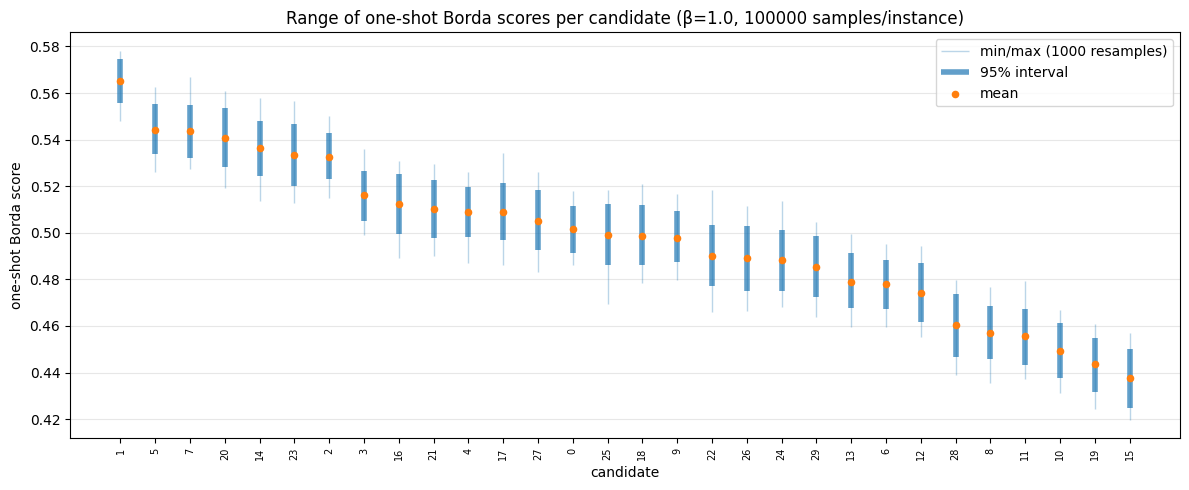

In [5]:
import matplotlib.pyplot as plt

order = df['candidate'].to_numpy()
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(12, 5))
ax.vlines(x, df['min'], df['max'], color='C0', alpha=0.3, linewidth=1, label=f'min/max ({n_resamples} resamples)')
ax.vlines(x, df['ci_lo'], df['ci_hi'], color='C0', linewidth=4, alpha=0.7, label=f'{int(ci*100)}% interval')
ax.scatter(x, df['mean'], color='C1', zorder=3, s=20, label='mean')

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_xlabel('candidate')
ax.set_ylabel('one-shot Borda score')
ax.set_title(f'Range of one-shot Borda scores per candidate (β={beta}, {num_samples} samples/instance)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
true_ranking = np.argsort(-population.avg_utilities)

def true_ranking_is_possible(true_ranking, lo, hi):
    ceiling = hi[true_ranking[0]]
    for c in true_ranking[1:]:
        if lo[c] >= ceiling:
            return False
        ceiling = min(hi[c], ceiling)
    return True

print('possible with min/max range:', true_ranking_is_possible(
    true_ranking, borda_score_range['min'], borda_score_range['max']))
print(f'possible with {int(ci*100)}% CI range:', true_ranking_is_possible(
    true_ranking, borda_score_range['ci_lo'], borda_score_range['ci_hi']))

possible with min/max range: True
possible with 95% CI range: True
